In [77]:
# Preprocesamiento de datos

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Entrenamiento de modelo

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import IsolationForest


In [78]:
cod = pd.read_csv('/Users/esemb/Desktop/code/cei/dl/datasets/cloud_outages_dataset.csv')

In [79]:
cod.sample(10)

,incident_id,cloud_provider,region,service,service_subtype,start_time,end_time,duration_minutes,severity,status,...,post_mortem_link,is_recurrent_issue,previous_incident_id,external_factors,scheduled_maintenance_conflict,patch_applied,system_load_before_outage,system_load_after_outage,backup_system_triggered,notes
35296,7baf5618-5ed0-4c75-9919-c7c4f59aed4f,GCP,us-west-2,Storage,RDS,2025-09-25 10:18:10.826500,2025-09-25 21:58:10.826500,700,Critical,Investigating,...,NaN,No,NaN,NaN,Yes,Yes,38,54,Yes,Simulated note
24356,43ea07ad-8ea2-463f-9d40-74cb5dd6adad,Azure,europe-west2,Storage,RDS,2025-02-20 10:18:10.150202,2025-02-20 10:25:10.150202,7,High,Monitoring,...,NaN,Yes,NaN,Weather,Yes,No,12,80,No,Simulated note
49515,b77af7fb-c45d-4da3-8c1e-86ec42ec037e,Oracle,asia-southeast1,Networking,VPC,2025-10-15 10:18:11.635692,2025-10-15 11:03:11.635692,45,Low,Resolved,...,NaN,No,NaN,Weather,Yes,Yes,34,63,Yes,Simulated note
28563,c94a21fb-03a6-4124-b40d-3f8e2b8470f5,Azure,us-west-2,Networking,Lambda,2025-10-29 10:18:10.423466,2025-10-29 19:39:10.423466,561,Critical,Monitoring,...,NaN,No,NaN,DDoS,Yes,Yes,95,89,No,Simulated note
35403,8f720762-f1a4-4656-9e70-68449bfc4489,Oracle,europe-west2,Networking,S3,2025-06-05 10:18:10.829897,2025-06-05 19:55:10.829897,577,Medium,Resolved,...,NaN,Yes,NaN,Weather,No,Yes,15,45,Yes,Simulated note
25684,5703ccd0-7abc-48d9-a111-1cbb384c0f9f,Oracle,us-west-2,AI/ML,Lambda,2025-12-13 10:18:10.238325,2025-12-13 15:36:10.238325,318,Low,Investigating,...,NaN,Yes,NaN,NaN,No,Yes,37,13,No,Simulated note
42053,b65c1bfc-bbc2-402b-8c97-f02b6d9400bb,IBM,europe-west2,AI/ML,BigQuery,2025-07-15 10:18:11.226064,2025-07-15 13:08:11.226064,170,Low,Monitoring,...,NaN,No,NaN,Vendor,Yes,Yes,27,27,Yes,Simulated note
36955,95617cd9-6074-4bbe-9b5b-eb598e57480b,IBM,us-west-2,Database,Lambda,2026-01-09 10:18:10.921221,2026-01-09 14:32:10.921221,254,Critical,Resolved,...,NaN,No,NaN,Weather,No,Yes,17,46,No,Simulated note
14210,ba06f804-fc10-4c20-b1d8-a490ddf5b70e,AWS,europe-west2,Database,S3,2026-01-14 10:18:09.503625,2026-01-14 10:43:09.503625,25,High,Resolved,...,NaN,No,NaN,NaN,Yes,Yes,28,32,No,Simulated note
10283,e786ec85-ad94-4ca8-9a1c-0c96eba72670,Oracle,us-east-1,Compute,RDS,2026-01-13 10:18:09.234984,2026-01-13 20:53:09.234984,635,Critical,Monitoring,...,NaN,No,NaN,Weather,No,No,69,91,No,Simulated note


In [80]:
cod['cloud_provider'].value_counts()

cloud_provider
IBM       10145
AWS       10060
Oracle    10033
Azure      9934
GCP        9828
Name: count, dtype: int64

In [81]:
cod.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   incident_id                     50000 non-null  str    
 1   cloud_provider                  50000 non-null  str    
 2   region                          50000 non-null  str    
 3   service                         50000 non-null  str    
 4   service_subtype                 50000 non-null  str    
 5   start_time                      50000 non-null  str    
 6   end_time                        50000 non-null  str    
 7   duration_minutes                50000 non-null  int64  
 8   severity                        50000 non-null  str    
 9   status                          50000 non-null  str    
 10  root_cause_category             50000 non-null  str    
 11  root_cause_description          50000 non-null  str    
 12  number_of_customers_affected    50000 non-n

In [82]:
cod['status'].value_counts()

status
Resolved         16797
Monitoring       16730
Investigating    16473
Name: count, dtype: int64

In [83]:
cod.isna().sum()

incident_id                           0
cloud_provider                        0
region                                0
service                               0
service_subtype                       0
start_time                            0
end_time                              0
duration_minutes                      0
severity                              0
status                                0
root_cause_category                   0
root_cause_description                0
number_of_customers_affected          0
estimated_revenue_loss_usd            0
sla_violation                         0
region_impact_score                   0
service_impact_score                  0
ticket_count                          0
ticket_response_time_minutes          0
ticket_resolution_time_minutes        0
monitoring_alerts_triggered           0
detection_method                      0
mitigation_action                     0
number_of_engineers_involved          0
engineer_response_time_minutes        0


In [84]:
int(cod['post_mortem_link'].isna().sum())

50000

In [85]:
int(cod['previous_incident_id'].isna().sum())

50000

In [86]:
int(cod['external_factors'].isna().sum())

12582

In [87]:
cod['external_factors'].value_counts()

external_factors
DDoS       12522
Vendor     12450
Weather    12446
Name: count, dtype: int64

In [88]:
cod['post_mortem_completed'].value_counts()

post_mortem_completed
No     25080
Yes    24920
Name: count, dtype: int64

In [89]:
cod['notes'].value_counts()

notes
Simulated note    50000
Name: count, dtype: int64

In [90]:
cod['root_cause_description'].value_counts()

root_cause_description
Simulated cause for ML    50000
Name: count, dtype: int64

#### Observaciones: 
- Tanto la columna `post_mortem_link` como `previous_incident_id` contienen valores nulos en su totalidad
- La columna `external_factors` tambien contiene una cantidad considerable de valores nulos
- La columna `notes` contiene únicamente el valor *"Simulated note"*
- La columna `root_cause_description`contiene únicamente el valor *"Simulated cause for ML"*

#### Acciones:
- Drop de `post_mortem_link`, `previous_incident_id`, `notes` y `root_cause_description`
- Drop de `incident_id`. No aporta ningun valor al modelo, esta incluida para bases de datos
- Se mantendrá la columna `external_factors` con especial atención a su impacto en los resultados de cada modelo


In [91]:
cod_v1 = cod.copy()

In [92]:
print(f'[Antes] cod_v1 shape: {cod_v1.shape}')

to_drop = ['post_mortem_link', 'previous_incident_id', 'notes', 'root_cause_description', 'incident_id']
for column_to_drop in to_drop:
    cod_v1.drop(column_to_drop, axis=1, inplace=True)

print(f'[Despues] cod_v1 shape: {cod_v1.shape}')


[Antes] cod_v1 shape: (50000, 40)
[Despues] cod_v1 shape: (50000, 35)


In [93]:
cod_v1.head()

,cloud_provider,region,service,service_subtype,start_time,end_time,duration_minutes,severity,status,root_cause_category,...,status_page_update_count,user_feedback_score,post_mortem_completed,is_recurrent_issue,external_factors,scheduled_maintenance_conflict,patch_applied,system_load_before_outage,system_load_after_outage,backup_system_triggered
0,AWS,europe-west2,Storage,S3,2025-06-30 10:18:08.524480,2025-06-30 13:15:08.524480,177,Low,Monitoring,Software,...,1,2,Yes,No,NaN,No,No,40,46,Yes
1,IBM,asia-southeast1,AI/ML,RDS,2025-06-28 10:18:08.524591,2025-06-28 20:52:08.524591,634,Low,Investigating,Security,...,2,5,Yes,No,Weather,Yes,No,45,55,Yes
2,AWS,europe-west2,Storage,S3,2025-06-01 10:18:08.524638,2025-06-01 14:36:08.524638,258,High,Resolved,Hardware,...,3,1,Yes,No,DDoS,No,Yes,61,74,No
3,AWS,asia-southeast1,Compute,Lambda,2025-11-30 10:18:08.524678,2025-11-30 19:21:08.524678,543,Medium,Resolved,Human Error,...,5,3,Yes,Yes,Weather,No,Yes,48,97,Yes
4,IBM,asia-southeast1,AI/ML,Cloud Functions,2025-02-16 10:18:08.524719,2025-02-16 21:03:08.524719,645,Medium,Monitoring,Security,...,1,1,No,No,DDoS,No,No,23,75,Yes


#### Conversión de features categóricas a valores numericos

In [95]:
cod_v1.dtypes.value_counts()

str        20
int64      14
float64     1
Name: count, dtype: int64

In [96]:
str_columns = []
for column in cod_v1.select_dtypes(include=['str']).columns:
    print(column)
    str_columns.append(column)

cloud_provider
region
service
service_subtype
start_time
end_time
severity
status
root_cause_category
sla_violation
detection_method
mitigation_action
communication_channels_used
public_status_page_updated
post_mortem_completed
is_recurrent_issue
external_factors
scheduled_maintenance_conflict
patch_applied
backup_system_triggered


In [97]:
for column in str_columns:
    print(f"{column}: {cod_v1[column].nunique()} unique values")

cloud_provider: 5 unique values
region: 4 unique values
service: 5 unique values
service_subtype: 7 unique values
start_time: 50000 unique values
end_time: 50000 unique values
severity: 4 unique values
status: 3 unique values
root_cause_category: 6 unique values
sla_violation: 2 unique values
detection_method: 3 unique values
mitigation_action: 4 unique values
communication_channels_used: 4 unique values
public_status_page_updated: 2 unique values
post_mortem_completed: 2 unique values
is_recurrent_issue: 2 unique values
external_factors: 3 unique values
scheduled_maintenance_conflict: 2 unique values
patch_applied: 2 unique values
backup_system_triggered: 2 unique values


In [98]:
print(f'Shape v1: {cod_v1.shape}')

Shape v1: (50000, 35)


In [99]:
# Dejo de lado las variables temporales para no generar 50.000 columnas

str_columns.remove('start_time')
str_columns.remove('end_time')
cod_v2 = pd.get_dummies(cod_v1, columns=str_columns, drop_first=False, dtype=int)



In [100]:
print(f'Shape v2: {cod_v2.shape} -- {cod_v2.shape[1] - cod_v1.shape[1]} columnas creadas')

Shape v2: (50000, 79) -- 44 columnas creadas


In [101]:
cod_v2.head()

,start_time,end_time,duration_minutes,number_of_customers_affected,estimated_revenue_loss_usd,region_impact_score,service_impact_score,ticket_count,ticket_response_time_minutes,ticket_resolution_time_minutes,...,is_recurrent_issue_Yes,external_factors_DDoS,external_factors_Vendor,external_factors_Weather,scheduled_maintenance_conflict_No,scheduled_maintenance_conflict_Yes,patch_applied_No,patch_applied_Yes,backup_system_triggered_No,backup_system_triggered_Yes
0,2025-06-30 10:18:08.524480,2025-06-30 13:15:08.524480,177,45023,882914.30,2,8,68,35,234,...,0,0,0,0,1,0,1,0,0,1
1,2025-06-28 10:18:08.524591,2025-06-28 20:52:08.524591,634,29036,589281.21,20,42,7,26,309,...,0,0,0,1,0,1,1,0,0,1
2,2025-06-01 10:18:08.524638,2025-06-01 14:36:08.524638,258,86689,130626.30,3,23,29,12,457,...,0,1,0,0,1,0,0,1,1,0
3,2025-11-30 10:18:08.524678,2025-11-30 19:21:08.524678,543,94893,472354.34,88,0,59,54,399,...,1,0,0,1,1,0,0,1,0,1
4,2025-02-16 10:18:08.524719,2025-02-16 21:03:08.524719,645,41905,312065.35,47,54,33,36,110,...,0,1,0,0,1,0,1,0,0,1


In [102]:
cod_v2[['start_time', 'end_time']]

,start_time,end_time
0,2025-06-30 10:18:08.524480,2025-06-30 13:15:08.524480
1,2025-06-28 10:18:08.524591,2025-06-28 20:52:08.524591
2,2025-06-01 10:18:08.524638,2025-06-01 14:36:08.524638
3,2025-11-30 10:18:08.524678,2025-11-30 19:21:08.524678
4,2025-02-16 10:18:08.524719,2025-02-16 21:03:08.524719
...,...,...
49995,2025-12-01 10:18:11.651560,2025-12-01 10:33:11.651560
49996,2025-12-27 10:18:11.651587,2025-12-27 12:02:11.651587
49997,2025-10-16 10:18:11.651615,2025-10-16 20:08:11.651615
49998,2025-04-05 10:18:11.651645,2025-04-05 15:48:11.651645



#### Tratamiento temporal

Transformación de `start_time` y `end_time` en información útil para el modelo. Primero, se convierten a `datetime` con `errors='coerce'` para manejar fechas inválidas sin romper el flujo. Luego, se ordena por tiempo para respetar la secuencia cronológica. Finalmente, se extraen variables numéricas (hora, día, mes, fin de semana) y se aplica codificación cíclica (seno/coseno) para preservar la naturaleza periódica del tiempo (por ejemplo, 23:00 y 00:00 son horas cercanas).

In [103]:
time_cols = ['start_time', 'end_time']
for col in time_cols:
    cod_v2[col] = pd.to_datetime(cod_v2[col], errors='coerce', utc=True)

cod_v2 = cod_v2.sort_values('start_time').reset_index(drop=True)

cod_v2['start_hour'] = cod_v2['start_time'].dt.hour
cod_v2['start_dayofweek'] = cod_v2['start_time'].dt.dayofweek
cod_v2['start_month'] = cod_v2['start_time'].dt.month
cod_v2['start_is_weekend'] = cod_v2['start_dayofweek'].isin([5, 6]).astype(int)

cod_v2['start_hour_sin'] = np.sin(2 * np.pi * cod_v2['start_hour'] / 24)
cod_v2['start_hour_cos'] = np.cos(2 * np.pi * cod_v2['start_hour'] / 24)
# dow = day of week
cod_v2['start_dow_sin'] = np.sin(2 * np.pi * cod_v2['start_dayofweek'] / 7)
cod_v2['start_dow_cos'] = np.cos(2 * np.pi * cod_v2['start_dayofweek'] / 7)

In [104]:
cod_v2.drop(columns=['start_time', 'end_time'], inplace=True)

cod_v2['duration_minutes'] = cod_v2['duration_minutes'].astype(float)

In [105]:
time_cols = [
    'duration_minutes',
    'start_hour', 'start_dayofweek', 'start_month', 'start_is_weekend',
    'start_hour_sin', 'start_hour_cos', 'start_dow_sin', 'start_dow_cos'
 ]

cod_v2[time_cols].sample(5)

,duration_minutes,start_hour,start_dayofweek,start_month,start_is_weekend,start_hour_sin,start_hour_cos,start_dow_sin,start_dow_cos
23059,641.0,10,1,7,0,0.5,-0.866025,0.781831,0.623490
43843,354.0,10,6,12,1,0.5,-0.866025,-0.781831,0.623490
48208,605.0,10,4,1,0,0.5,-0.866025,-0.433884,-0.900969
27783,24.0,10,1,9,0,0.5,-0.866025,0.781831,0.623490
17227,671.0,10,1,6,0,0.5,-0.866025,0.781831,0.623490


In [106]:
cod_v2['start_hour_sin'].value_counts()

start_hour_sin
0.5    50000
Name: count, dtype: int64

In [107]:
cod_v2['start_hour'].value_counts()

start_hour
10    50000
Name: count, dtype: int64

#### Extracción de features relevantes para el caso de estudio



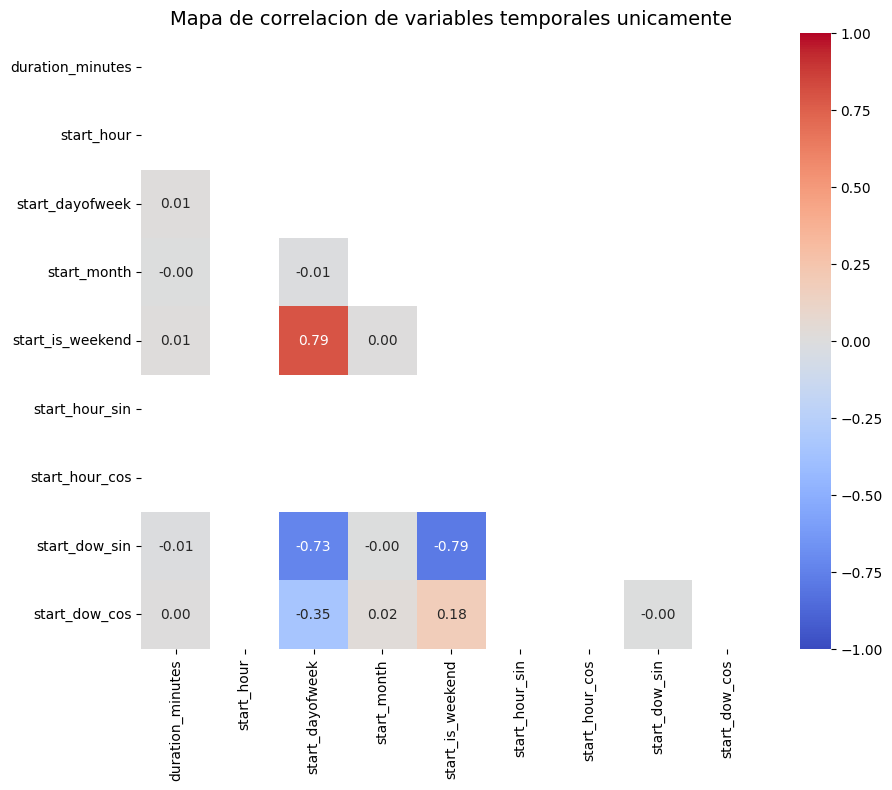

In [108]:
plt.figure(figsize=(10, 8))

corr_matrix = cod_v2[time_cols].corr()

# Máscara para ocultar el triángulo superior (que es redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1)

plt.title('Mapa de correlacion de variables temporales unicamente', fontsize=14)
plt.show()

#### Observaciónes: 
- Algunas variables temporales derivadas tienen **varianza nula** (mismo valor en todos los registros). 

#### Acciónes
- Drop de `start_hour`, `start_hour_sin`, `start_hour_cos`. No aportan valor al entrenamiento del modelo. 

In [109]:
cod_v2.drop(columns=['start_hour', 'start_hour_sin', 'start_hour_cos'], inplace=True)

In [110]:
cod_v2.sample(5)

,duration_minutes,number_of_customers_affected,estimated_revenue_loss_usd,region_impact_score,service_impact_score,ticket_count,ticket_response_time_minutes,ticket_resolution_time_minutes,monitoring_alerts_triggered,number_of_engineers_involved,...,scheduled_maintenance_conflict_Yes,patch_applied_No,patch_applied_Yes,backup_system_triggered_No,backup_system_triggered_Yes,start_dayofweek,start_month,start_is_weekend,start_dow_sin,start_dow_cos
14145,402.0,76562,69971.70,52,94,1,56,444,19,5,...,1,1,0,0,1,6,5,1,-0.781831,0.623490
21256,344.0,45727,325447.33,51,34,70,28,207,8,7,...,0,0,1,1,0,3,7,0,0.433884,-0.900969
26512,698.0,43801,131038.94,60,68,42,34,446,8,5,...,0,0,1,1,0,6,8,1,-0.781831,0.623490
15869,264.0,15166,778352.14,65,50,27,36,380,10,3,...,1,1,0,0,1,5,6,1,-0.974928,-0.222521
9702,477.0,40874,846007.36,10,65,34,46,188,1,9,...,0,1,0,0,1,3,4,0,0.433884,-0.900969


In [111]:
time_cols = [
    'duration_minutes', 'start_dayofweek', 'start_month', 'start_is_weekend', 'start_dow_sin', 'start_dow_cos'
 ]

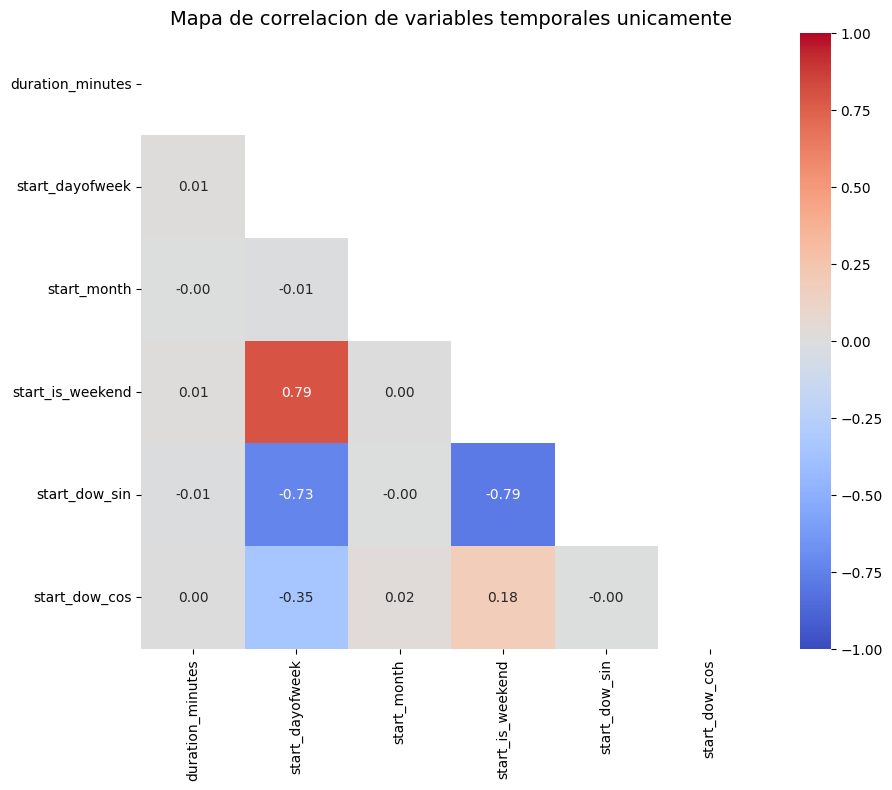

In [112]:
plt.figure(figsize=(10, 8))

corr_matrix = cod_v2[time_cols].corr()

# Máscara para ocultar el triángulo superior (que es redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1)

plt.title('Mapa de correlacion de variables temporales unicamente', fontsize=14)
plt.show()

In [113]:
print(f'Shape: {cod_v2.shape}')

Shape: (50000, 82)


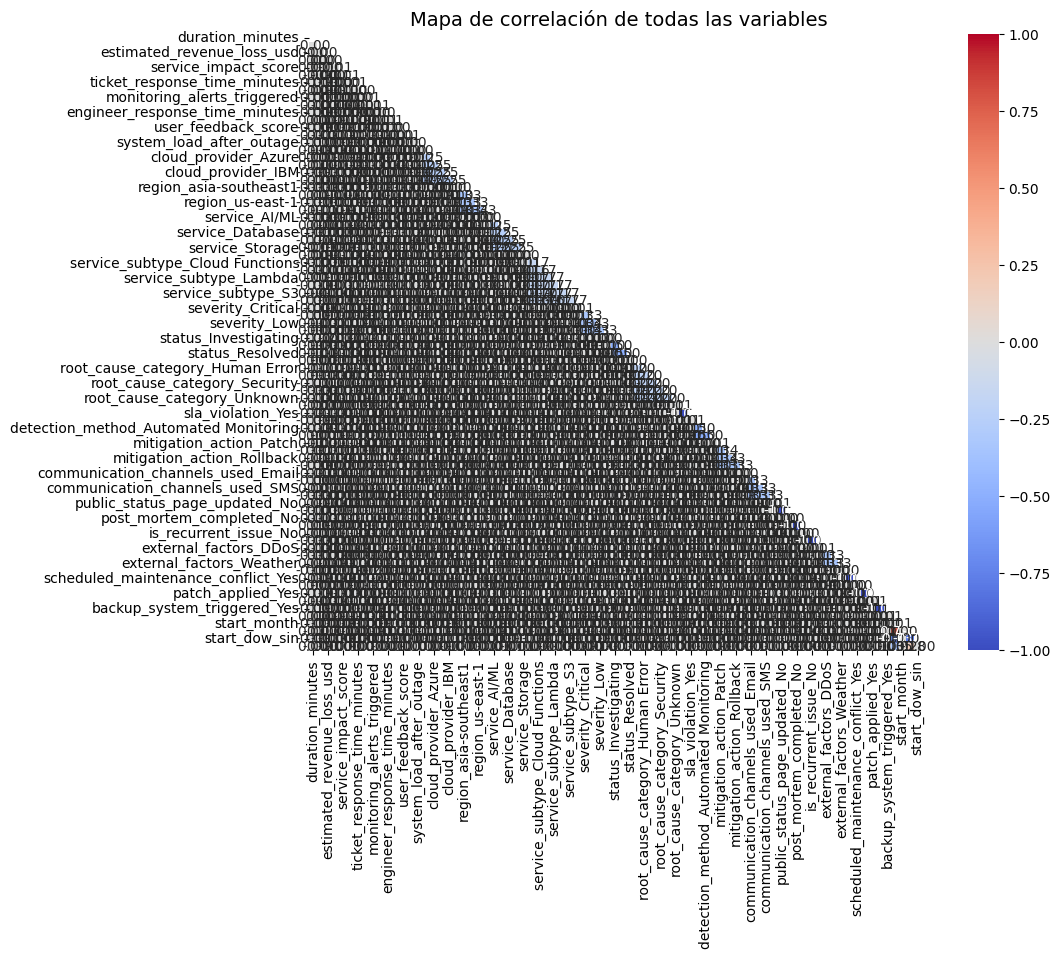

In [114]:
plt.figure(figsize=(10, 8))

corr_matrix = cod_v2.corr()

# Máscara para ocultar el triángulo superior (que es redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1)

plt.title('Mapa de correlación de todas las variables', fontsize=14)
plt.show()

##### Filtro de matriz por pares de variables con fuerte relacion entre si ( > 0.5 )

Pares de variables altamente correlacionadas (>0.5):
--------------------------------------------------
scheduled_maintenance_conflict_No  scheduled_maintenance_conflict_Yes      -1.000000
backup_system_triggered_No         backup_system_triggered_Yes             -1.000000
post_mortem_completed_Yes          post_mortem_completed_No                -1.000000
sla_violation_No                   sla_violation_Yes                       -1.000000
public_status_page_updated_No      public_status_page_updated_Yes          -1.000000
patch_applied_No                   patch_applied_Yes                       -1.000000
is_recurrent_issue_Yes             is_recurrent_issue_No                   -1.000000
start_dayofweek                    start_is_weekend                         0.791681
start_dow_sin                      start_is_weekend                        -0.787765
start_dayofweek                    start_dow_sin                           -0.733965
status_Monitoring                  status_Reso

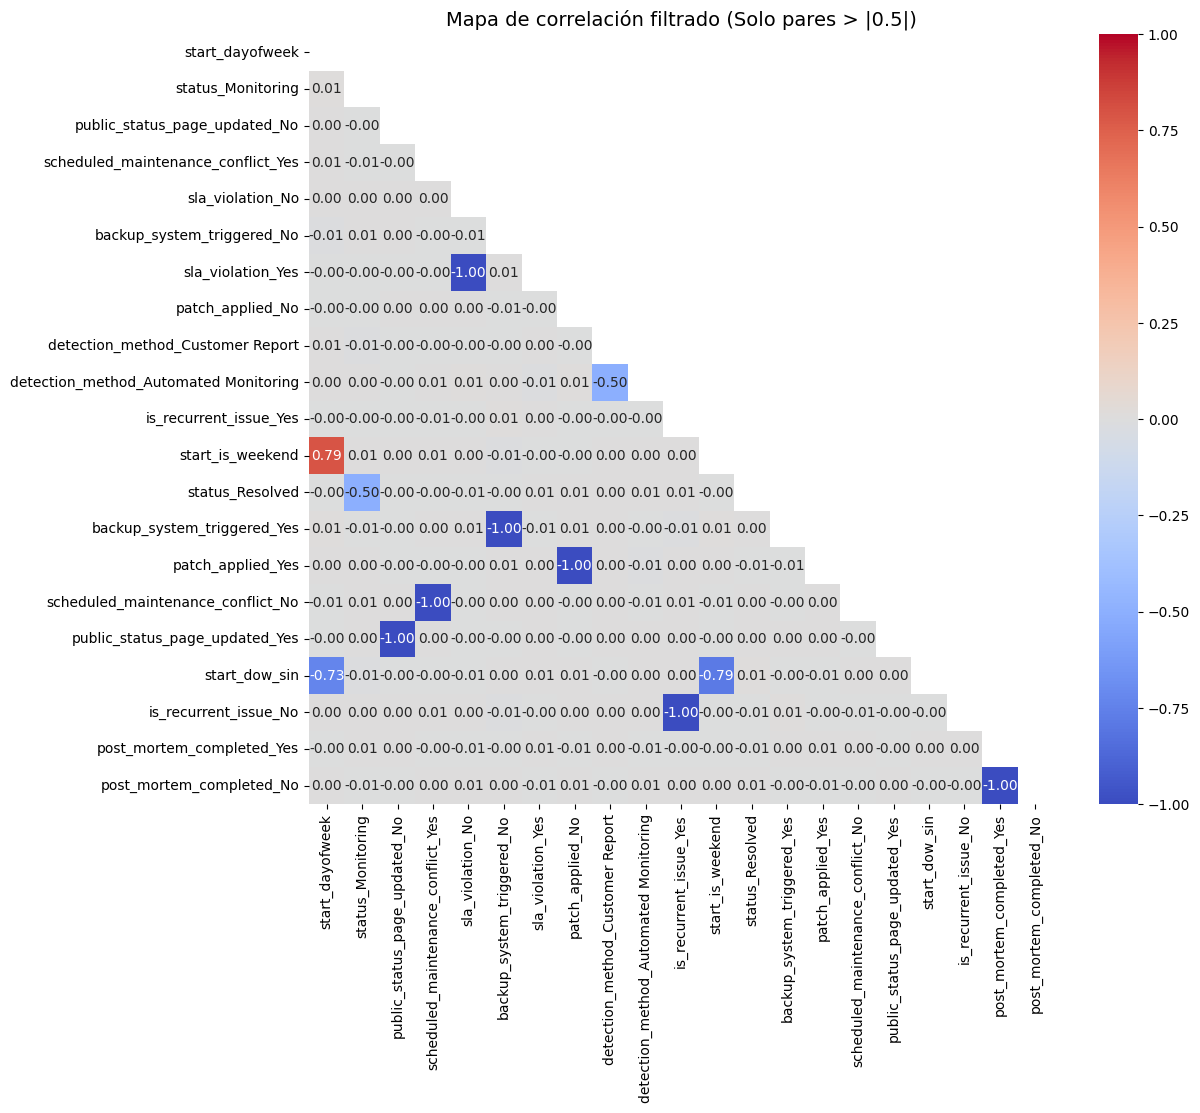

In [115]:
corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

strong_pairs = sorted_pairs[(abs(sorted_pairs) > 0.5) & (sorted_pairs != 1.0)][::2]

print("Pares de variables altamente correlacionadas (>0.5):")
print("-" * 50)
print(strong_pairs)

features_to_plot = set()
for var1, var2 in strong_pairs.index:
    features_to_plot.add(var1)
    features_to_plot.add(var2)

features_to_plot = list(features_to_plot)

filtered_corr_matrix = cod_v2[features_to_plot].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))

sns.heatmap(filtered_corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title('Mapa de correlación filtrado (Solo pares > |0.5|)', fontsize=14)
plt.show()

#### Observaciónes: 
- Las variables altamente relacionadas > 0.8 eran esperadas, ya que su origen era binario (yes, no), por lo tanto se eliminaran. Esto se podria haber evitado con drop_first=True en la funcion get_dummies, pero hubiera generado un problema en las variables no binarias. Las restantes, tambien altamente relacionadas, persistiran con especial atencion a los resultados del modelo ya que se estima que agregaran valor temporal.  

#### Acciónes
- Drop de `scheduled_maintenance_conflict_No`, `backup_system_triggered_No`, `post_mortem_completed_No`, `sla_violation_No`, `public_status_page_updated_No`, `patch_applied_No`, `is_recurrent_issue_No`. 

In [116]:
cod_v2.shape

(50000, 82)

In [117]:
cod_v2.drop([
    'scheduled_maintenance_conflict_No', 'backup_system_triggered_No',
    'post_mortem_completed_No', 'sla_violation_No', 'public_status_page_updated_No',
    'patch_applied_No', 'is_recurrent_issue_No'
], axis=1, inplace=True)

In [118]:
cod_v2.shape

(50000, 75)

Pares de variables altamente correlacionadas (>0.5):
--------------------------------------------------
start_dayofweek                        start_is_weekend                    0.791681
start_dow_sin                          start_is_weekend                   -0.787765
start_dayofweek                        start_dow_sin                      -0.733965
status_Resolved                        status_Monitoring                  -0.504369
detection_method_Automated Monitoring  detection_method_Customer Report   -0.502178
dtype: float64


<Figure size 1000x800 with 0 Axes>

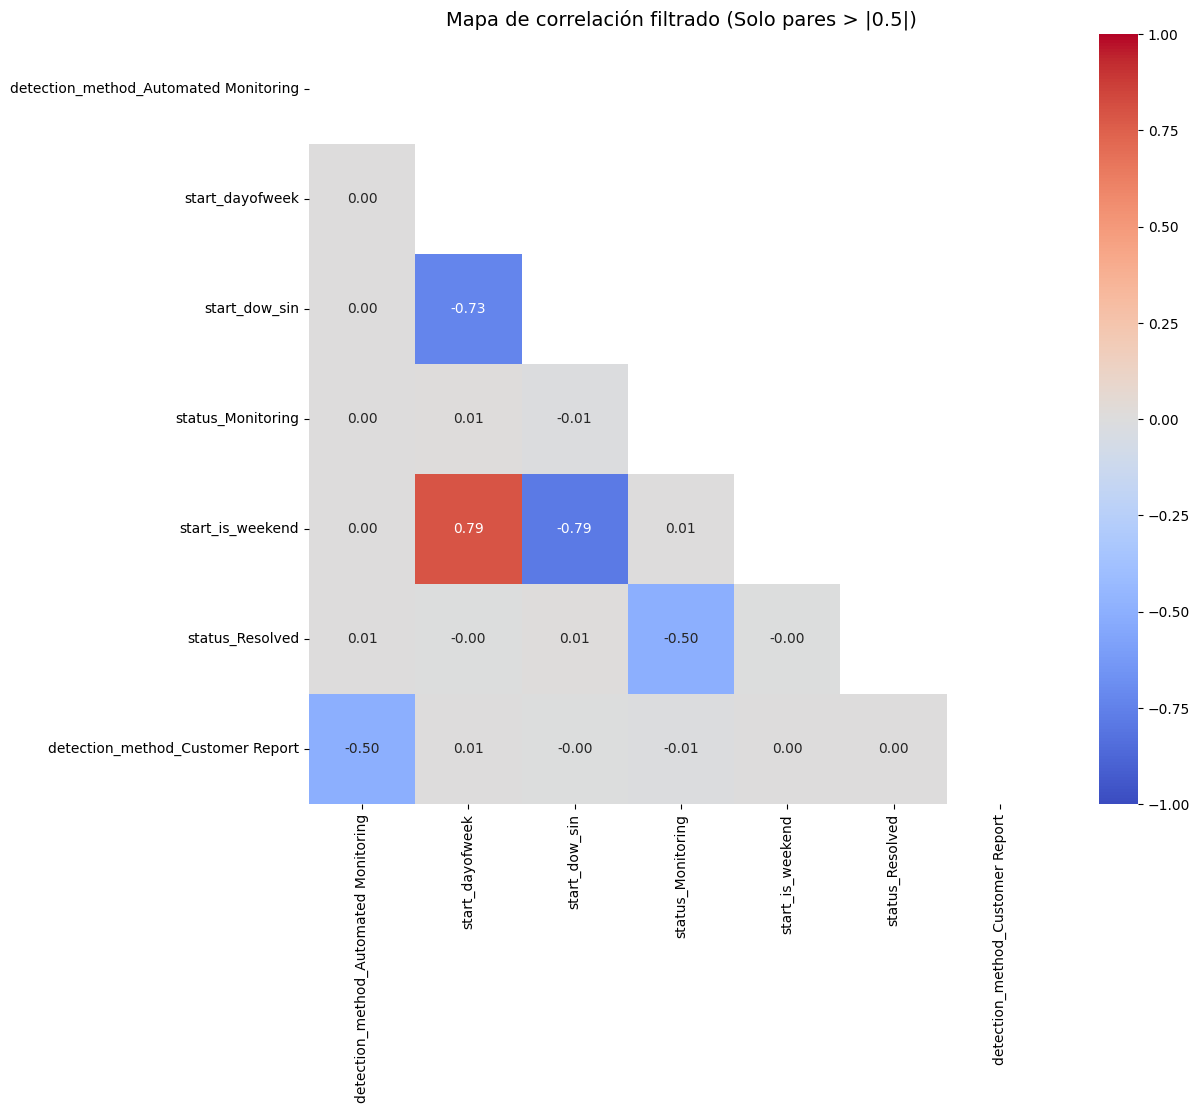

In [119]:
plt.figure(figsize=(10, 8))

corr_matrix = cod_v2.corr()

corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

strong_pairs = sorted_pairs[(abs(sorted_pairs) > 0.5) & (sorted_pairs != 1.0)][::2]

print("Pares de variables altamente correlacionadas (>0.5):")
print("-" * 50)
print(strong_pairs)

features_to_plot = set()
for var1, var2 in strong_pairs.index:
    features_to_plot.add(var1)
    features_to_plot.add(var2)

features_to_plot = list(features_to_plot)

filtered_corr_matrix = cod_v2[features_to_plot].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))

sns.heatmap(filtered_corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            mask=mask, 
            vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title('Mapa de correlación filtrado (Solo pares > |0.5|)', fontsize=14)
plt.show()

#### Estandarización

1. Se evaluará la distribución y varianza de las variables
2. Aquellas con distribuciónes sesgadas o varianzas muy distintas se visualizarán con graficos para justificar acciones posteriores
3. Proceso de estandarización con normalización logaritmica o StandardScaler una vez divididos los datos de entrenamiento y test

In [120]:
with pd.option_context('display.max_columns', None):
    display(cod_v2.describe())

,duration_minutes,number_of_customers_affected,estimated_revenue_loss_usd,region_impact_score,service_impact_score,ticket_count,ticket_response_time_minutes,ticket_resolution_time_minutes,monitoring_alerts_triggered,number_of_engineers_involved,engineer_response_time_minutes,status_page_update_count,user_feedback_score,system_load_before_outage,system_load_after_outage,cloud_provider_AWS,cloud_provider_Azure,cloud_provider_GCP,cloud_provider_IBM,cloud_provider_Oracle,region_asia-southeast1,region_europe-west2,region_us-east-1,region_us-west-2,service_AI/ML,service_Compute,service_Database,service_Networking,service_Storage,service_subtype_BigQuery,service_subtype_Cloud Functions,service_subtype_EC2,service_subtype_Lambda,service_subtype_RDS,service_subtype_S3,service_subtype_VPC,severity_Critical,severity_High,severity_Low,severity_Medium,status_Investigating,status_Monitoring,status_Resolved,root_cause_category_Hardware,root_cause_category_Human Error,root_cause_category_Network,root_cause_category_Security,root_cause_category_Software,root_cause_category_Unknown,sla_violation_Yes,detection_method_Alert,detection_method_Automated Monitoring,detection_method_Customer Report,mitigation_action_Patch,mitigation_action_Restart,mitigation_action_Rollback,mitigation_action_Scale Up,communication_channels_used_Email,communication_channels_used_PagerDuty,communication_channels_used_SMS,communication_channels_used_Slack,public_status_page_updated_Yes,post_mortem_completed_Yes,is_recurrent_issue_Yes,external_factors_DDoS,external_factors_Vendor,external_factors_Weather,scheduled_maintenance_conflict_Yes,patch_applied_Yes,backup_system_triggered_Yes,start_dayofweek,start_month,start_is_weekend,start_dow_sin,start_dow_cos
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,361.312020,50297.95150,501118.383462,49.903620,49.974180,50.439280,32.554720,254.586100,10.552140,5.498960,32.503160,2.502740,2.997120,55.129780,54.900920,0.201200,0.198680,0.196560,0.202900,0.200660,0.248920,0.252040,0.24608,0.252960,0.196680,0.202240,0.20264,0.200260,0.198180,0.141120,0.143640,0.141340,0.14614,0.142360,0.143480,0.141920,0.254740,0.246920,0.250780,0.247560,0.329460,0.334600,0.335940,0.166340,0.165260,0.16624,0.168900,0.165980,0.167280,0.503360,0.331400,0.333700,0.33490,0.251700,0.250620,0.250660,0.247020,0.248320,0.250200,0.250740,0.250740,0.504560,0.498400,0.499360,0.250440,0.249000,0.248920,0.501780,0.496380,0.504140,3.006920,6.532100,0.287620,-0.001097,-0.002323
std,206.389101,28848.84549,288268.246858,29.169404,29.113495,28.907151,16.166142,130.332934,5.756397,2.873187,16.072899,1.715882,1.415214,26.356675,26.224833,0.400901,0.399011,0.397401,0.402163,0.400498,0.432392,0.434188,0.43073,0.434713,0.397492,0.401674,0.40197,0.400199,0.398632,0.348149,0.350728,0.348375,0.35325,0.349422,0.350565,0.348972,0.435719,0.431224,0.433466,0.431599,0.470022,0.471855,0.472323,0.372389,0.371419,0.37230,0.374667,0.372066,0.373229,0.499994,0.470721,0.471539,0.47196,0.433994,0.433374,0.433397,0.431283,0.432043,0.433132,0.433443,0.433443,0.499984,0.500002,0.5

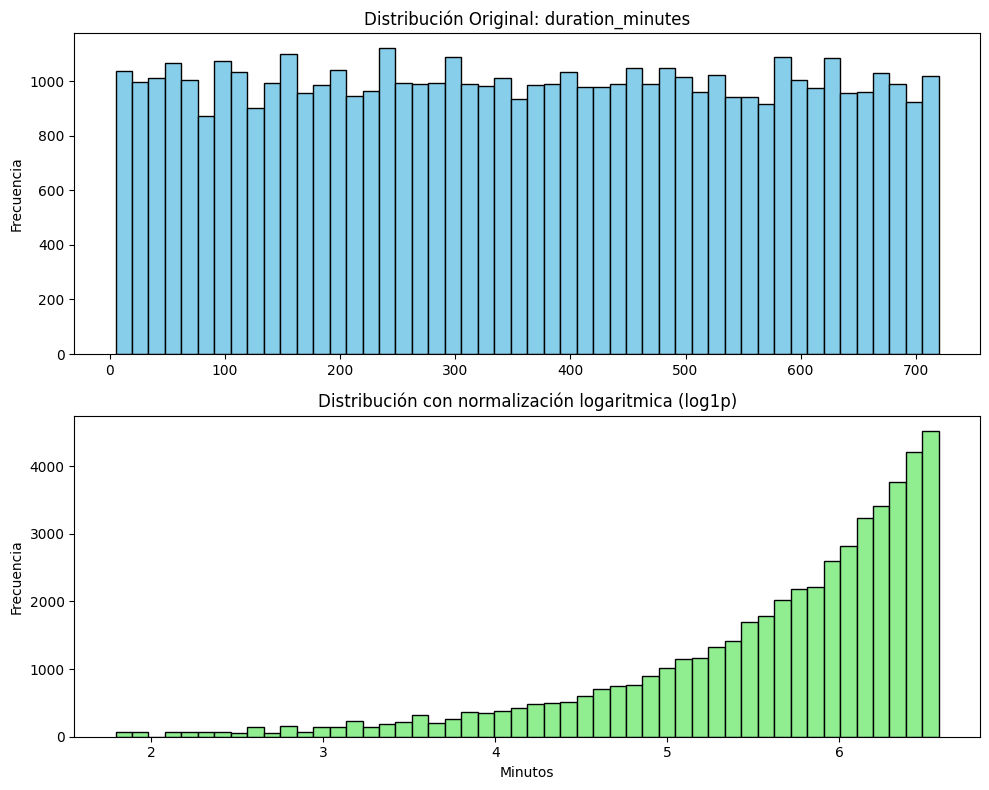

In [121]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(cod_v2['duration_minutes'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución Original: duration_minutes')
axes[0].set_ylabel('Frecuencia')

log_duration = np.log1p(cod_v2['duration_minutes'])

axes[1].hist(log_duration, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución con normalización logaritmica (log1p)')
axes[1].set_xlabel('Minutos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

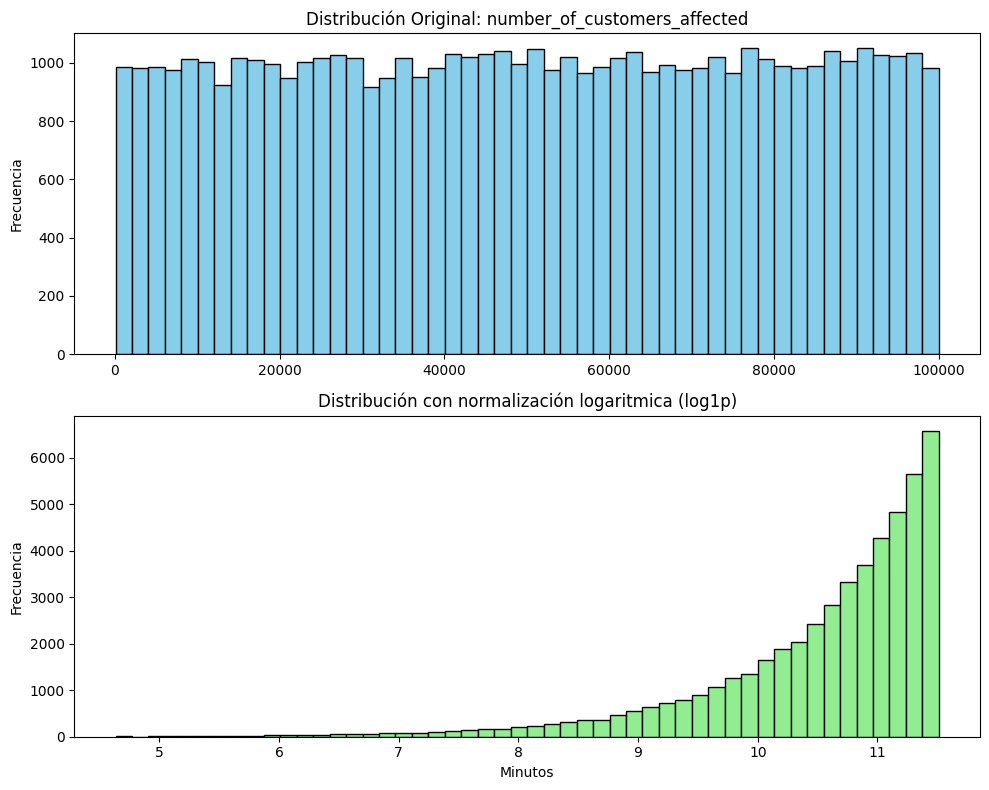

In [122]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(cod_v2['number_of_customers_affected'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución Original: number_of_customers_affected')
axes[0].set_ylabel('Frecuencia')

log_duration = np.log1p(cod_v2['number_of_customers_affected'])

axes[1].hist(log_duration, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución con normalización logaritmica (log1p)')
axes[1].set_xlabel('Minutos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

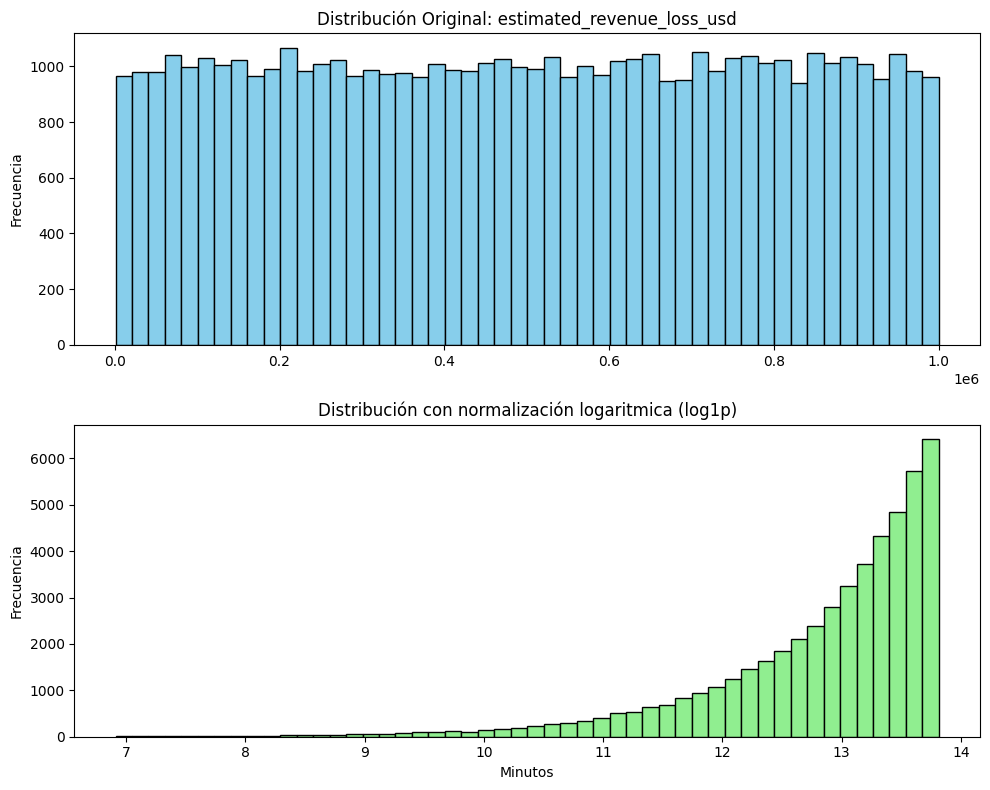

In [123]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(cod_v2['estimated_revenue_loss_usd'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución Original: estimated_revenue_loss_usd')
axes[0].set_ylabel('Frecuencia')

log_duration = np.log1p(cod_v2['estimated_revenue_loss_usd'])

axes[1].hist(log_duration, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución con normalización logaritmica (log1p)')
axes[1].set_xlabel('Minutos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

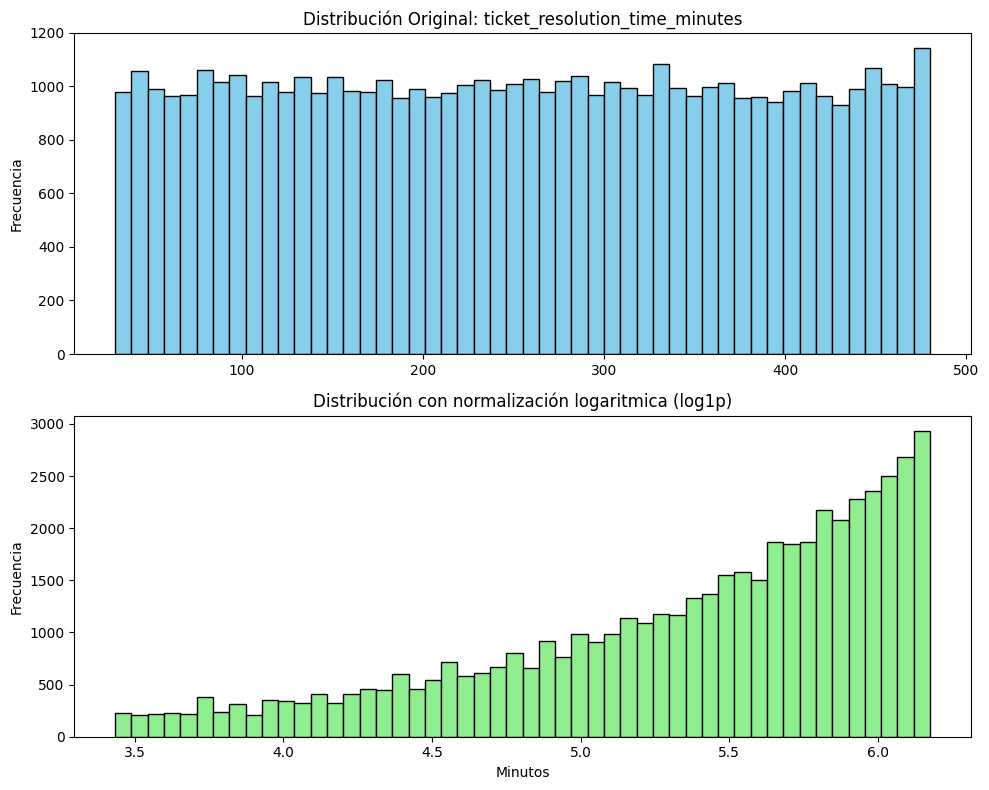

In [124]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(cod_v2['ticket_resolution_time_minutes'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución Original: ticket_resolution_time_minutes')
axes[0].set_ylabel('Frecuencia')

log_duration = np.log1p(cod_v2['ticket_resolution_time_minutes'])

axes[1].hist(log_duration, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución con normalización logaritmica (log1p)')
axes[1].set_xlabel('Minutos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### Observaciónes

- Se observó que la aplicación de normalización logarítmica perjudica la distribución generando una cola hacia la izquierda

#### Acciones

- Se omitirá la aplicación de normalización logarítmica al ser muy agresiva. Se procederá con StandardScaler sobre las variables continuas una vez divididos los datos en train y test

In [125]:
cod_v2.shape

(50000, 75)

In [126]:
with pd.option_context('display.max_columns', None):
    display(cod_v2.head())

,duration_minutes,number_of_customers_affected,estimated_revenue_loss_usd,region_impact_score,service_impact_score,ticket_count,ticket_response_time_minutes,ticket_resolution_time_minutes,monitoring_alerts_triggered,number_of_engineers_involved,engineer_response_time_minutes,status_page_update_count,user_feedback_score,system_load_before_outage,system_load_after_outage,cloud_provider_AWS,cloud_provider_Azure,cloud_provider_GCP,cloud_provider_IBM,cloud_provider_Oracle,region_asia-southeast1,region_europe-west2,region_us-east-1,region_us-west-2,service_AI/ML,service_Compute,service_Database,service_Networking,service_Storage,service_subtype_BigQuery,service_subtype_Cloud Functions,service_subtype_EC2,service_subtype_Lambda,service_subtype_RDS,service_subtype_S3,service_subtype_VPC,severity_Critical,severity_High,severity_Low,severity_Medium,status_Investigating,status_Monitoring,status_Resolved,root_cause_category_Hardware,root_cause_category_Human Error,root_cause_category_Network,root_cause_category_Security,root_cause_category_Software,root_cause_category_Unknown,sla_violation_Yes,detection_method_Alert,detection_method_Automated Monitoring,detection_method_Customer Report,mitigation_action_Patch,mitigation_action_Restart,mitigation_action_Rollback,mitigation_action_Scale Up,communication_channels_used_Email,communication_channels_used_PagerDuty,communication_channels_used_SMS,communication_channels_used_Slack,public_status_page_updated_Yes,post_mortem_completed_Yes,is_recurrent_issue_Yes,external_factors_DDoS,external_factors_Vendor,external_factors_Weather,scheduled_maintenance_conflict_Yes,patch_applied_Yes,backup_system_triggered_Yes,start_dayofweek,start_month,start_is_weekend,start_dow_sin,start_dow_cos
0,501.0,41098,612943.79,61,49,29,45,192,3,7,55,3,2,32,79,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,2,2,0,0.974928,-0.222521
1,77.0,66025,679847.04,57,15,11,31,396,2,2,45,2,4,45,57,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,1,2,2,0,0.974928,-0.222521
2,219.0,46511,235343.09,29,0,69,31,75,6,2,11,0,5,91,55,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,2,2,0,0.974928,-0.222521
3,7.0,4242,532819.29,57,12,72,43,153,3,7,22,3,5,55,64,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,1,0,1,0,0,1,1,0,1,2,2,0,0.974928,-0.222521
4,505.0,49180,363630.30,63,72,25,47,322,13,6,27,3,3,71,32,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,2,2,0,0.974928,-0.222521


#### Definición de `is_anomaly`

Se define un label `is_anomaly` como la conjunción de tres condiciones:
severidad crítica, violación de SLA, y duración del incidente superior al percentil 90. Esta etiqueta
no se utiliza durante el entrenamiento — el modelo es completamente no supervisado.
Su único propósito es la evaluación posterior de las anomalías detectadas.

In [127]:
cod_v2['severity_Critical'].value_counts()

severity_Critical
0    37263
1    12737
Name: count, dtype: int64

In [128]:
cod_v2['sla_violation_Yes'].value_counts()

sla_violation_Yes
1    25168
0    24832
Name: count, dtype: int64

In [129]:
cod_v2[cod_v2['duration_minutes'] > cod_v2['duration_minutes'].quantile(0.9)].info

<bound method DataFrame.info of        duration_minutes  number_of_customers_affected  \
14                692.0                         18017   
16                689.0                         18176   
24                653.0                           999   
25                665.0                         21985   
36                679.0                          9470   
...                 ...                           ...   
49973             659.0                         33727   
49974             706.0                         16464   
49975             705.0                         99766   
49990             684.0                         32219   
49993             660.0                         60177   

       estimated_revenue_loss_usd  region_impact_score  service_impact_score  \
14                      817718.73                    2                    42   
16                      281719.48                   89                    33   
24                       61614.33          

#### División de datos
- Se dividirán los datos en train, val y test preservando el orden cronológico (requisito de LSTMs)
- Se prescindirá de una división random para prevenir sesgos y simular un entorno productivo

In [130]:
n = len(cod_v2)

train_end = int(n * 0.70) 
val_end = int(n * 0.85)

# Ordenamiento cronológico:
## Entrenamiento: filas 0 -> 34.999 (35.000 datos)
## Validación: filas 35000 -> 42.499 (7.500 datos)
## Test: filas 42.499 -> 49.999 (7.500 datos)

df_train = cod_v2.iloc[:train_end].reset_index(drop=True) # 70% datos de entrenamiento
df_val = cod_v2.iloc[train_end:val_end].reset_index(drop=True) # 15% datos de validación
df_test  = cod_v2.iloc[val_end:].reset_index(drop=True) # 15% datos de test

print(f"Train: {len(df_train)} rows ({int(len(df_train)/n * 100)}%)")
print(f"Val: {len(df_val)} rows ({int(len(df_val)/n * 100)}%)")
print(f"Test: {len(df_test)} rows ({int(len(df_test)/n * 100)}%)")

Train: 35000 rows (70%)
Val: 7500 rows (15%)
Test: 7500 rows (15%)


In [131]:
# is_anomaly = (cod_v2['severity_Critical'] == 1) & (cod_v2['sla_violation_Yes'] == 1) & (cod_v2['duration_minutes'] > cod_v2['duration_minutes'].quantile(0.9))

In [132]:
# print(f"Total: {is_anomaly.sum()} de 50.000 incidentes")
# print(f"Porcentaje de anomalias: {is_anomaly.mean() * 100:0.2f}%")

In [133]:
# Umbrales basados en percentil 90 del dataset completo
p90_duration   = cod_v2['duration_minutes'].quantile(0.90)
p90_customers  = cod_v2['number_of_customers_affected'].quantile(0.90)
p90_revenue    = cod_v2['estimated_revenue_loss_usd'].quantile(0.90)

# Condiciones individuales
cond_duration  = cod_v2['duration_minutes']              > p90_duration
cond_customers = cod_v2['number_of_customers_affected']  > p90_customers
cond_revenue   = cod_v2['estimated_revenue_loss_usd']    > p90_revenue

# Anómalo si al menos 2 de 3 condiciones se cumplen simultáneamente
is_anomaly = (cond_duration.astype(int) + 
              cond_customers.astype(int) + 
              cond_revenue.astype(int)) >= 2

print(f"Total anomalías : {is_anomaly.sum():,}")
print(f"Tasa de anomalía: {is_anomaly.mean():.2%}")

Total anomalías : 1,383
Tasa de anomalía: 2.77%


In [134]:
anomaly_test = is_anomaly.iloc[val_end:].reset_index(drop=True)

print(f"anomaly_test shape  : {anomaly_test.shape}")
print(f"True anomalies      : {anomaly_test.sum()}")
print(f"Anomaly rate        : {anomaly_test.mean():.2%}")

anomaly_test shape  : (7500,)
True anomalies      : 188
Anomaly rate        : 2.51%


#### Escalado

- StandardScaler a todas las variables de entrenamiento, y transform en las restantes (val y test)

In [135]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_train)
val_scaled = scaler.transform(df_val)
test_scaled = scaler.transform(df_test)

In [136]:
train_scaled[0]

array([ 0.67370505, -0.31952058,  0.38695149,  0.3792613 , -0.03515347,
       -0.73771921,  0.76644343, -0.47957718, -1.31612448,  0.52692946,
        1.40049086,  0.28906194, -0.70220993, -0.87882966,  0.91860467,
        1.98161596, -0.49718589, -0.49571053, -0.50343518, -0.49901766,
       -0.57576668, -0.57915381,  1.75410327, -0.5843887 , -0.49629184,
       -0.50249877, -0.50133893,  1.98846639, -0.49696241, -0.40595934,
       -0.40591159, -0.40438243, -0.41479891, -0.40786718,  2.43052264,
       -0.40734291, -0.58254103, -0.57365519,  1.73257883, -0.57603061,
       -0.70167399, -0.70794032,  1.40505062, -0.44650809, -0.44388215,
        2.2405249 , -0.45348575, -0.44613985, -0.44692224, -1.00734123,
       -0.70140196,  1.40253609, -0.70694011, -0.58100136, -0.57875791,
        1.73840844, -0.57440301,  1.74173827, -0.578406  , -0.58029752,
       -0.57655847,  0.99469976, -0.99271227, -0.99874365, -0.57677842,
       -0.5788019 ,  1.73867435, -1.00389329,  1.00693836, -1.00

In [137]:
len(train_scaled[0])

75

#### Diseño de modelo / Transformación de datos de entrada

- Actualmente, los datos de entrada tienen dimensión 2D (filas, variables). Cada fila es un incidente representado como un vector de 75 numeros
- Tomando en cuenta referencias externas acerca de las redes recurrentes (específicamente, las LSTM Autoencoder), una de las transoformaciones mas necesarias es la creación de ventanas superpuestas para establecer secuencias cronológicas, dado que este tipo de modelos operan sobre secuencias, con el objetivo de aprender el patrón temporal entre los incidentes de cada ventana y despues reconstruirlo
- Se procederá a crear las mismas con una longitud de 20 registros por cada una (stride 1) con el objetivo de crear tensores con una dimensión 3D: (samples, timesteps, features)
    - samples: numero de ventanas
    - timesteps: 20 (longitud de ventana)
    - features: 75

In [138]:
WINDOW_SIZE = 20

In [139]:
def create_windows(data, window_size):
    n_windows = len(data) - window_size + 1
    output_array = np.array([data[i : i + window_size] for i in range(n_windows)])
    return output_array

In [140]:
X_train = create_windows(train_scaled, WINDOW_SIZE)
X_val = create_windows(val_scaled, WINDOW_SIZE)
X_test = create_windows(test_scaled, WINDOW_SIZE)

print(f"Final shape: \nX_train: {X_train.shape} \nX_val: {X_val.shape}  \nX_test: {X_test.shape}")

Final shape: 
X_train: (34981, 20, 75) 
X_val: (7481, 20, 75)  
X_test: (7481, 20, 75)


#### Arquitectura del modelo

- Definición: LSTM Autoencoder
- Consiste en un encoder LSTM que transorma cada ventana temporal de 20 incidentes en un vector latente con una dimensión de 64 unidades
- Una vez comprimido, un RepeatVector actua como "puente" que reconstruye la dimension temporal/secuencial
- El decoder, también LSTM, y finalmente una capa densa de tipo TimeDistributed que proyecta cada secuencia temporal denuevo a 75 features

In [141]:
inputs = Input(shape=(20, 75))

endoded = LSTM(64, activation='tanh', return_sequences=False)(inputs)

repeated = RepeatVector(20)(endoded)

decoded = LSTM(64, activation='tanh', return_sequences=True)(repeated)

outputs = TimeDistributed(Dense(75))(decoded)

In [142]:
model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 75)         │         4,875 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,739 (288.04 KB)

 Trainable params: 73,739 (288.04 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
early_stop = EarlyStopping(
    monitor   = 'val_loss',    
    patience  = 5, 
    restore_best_weights = True,  
    verbose   = 1
)

history = model.fit(
    X_train, X_train,  
    epochs = 50,
    batch_size = 32,
    validation_data = (X_val, X_val), 
    callbacks = [early_stop],
    shuffle = False,
    verbose = 1 
)



Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.6600 - val_loss: 0.6808
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6465 - val_loss: 0.6425
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6383 - val_loss: 0.6355
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6351 - val_loss: 0.6330
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6325 - val_loss: 0.6343
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6299 - val_loss: 0.6299
Epoch 7/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6269 - val_loss: 0.6299
Epoch 8/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6257 - val_loss: 0.6300
Epoch 9/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6245 - val_loss: 0.6291
Epoch 10/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6235 - val_loss: 0.6289
Epoch 11/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.6228 - val_loss: 0.6258
Epoch 12

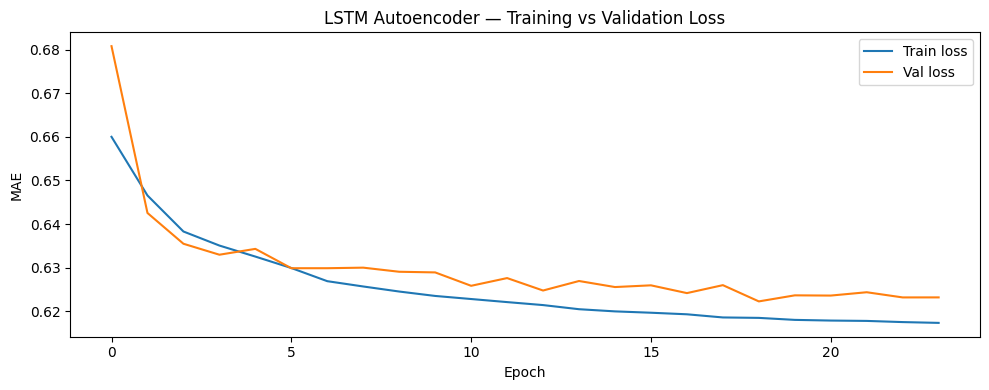

In [144]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('LSTM Autoencoder — Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

Val  MAE — mean: 0.6223, std: 0.0099
Val  MAE — min:  0.5844,  max: 0.6621
Test MAE — mean: 0.6326, std: 0.0105


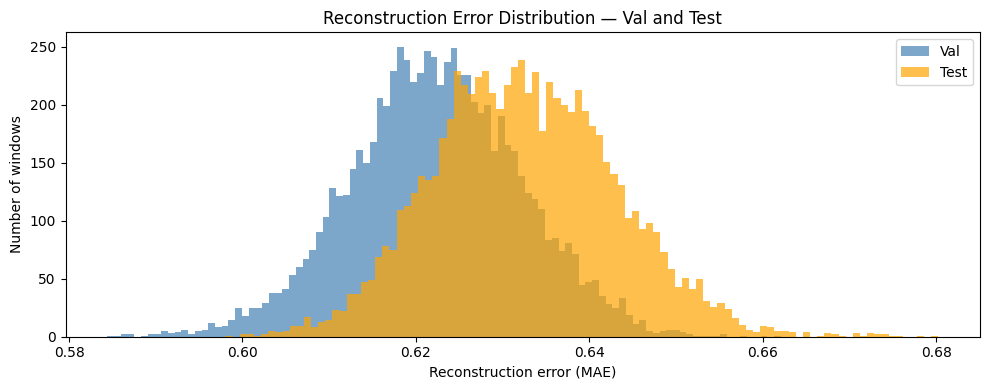

In [145]:
# Predict reconstructed sequences for val and test
X_val_pred  = model.predict(X_val,  verbose=0)
X_test_pred = model.predict(X_test, verbose=0)

# Per-sample MAE: mean across timesteps and features
val_mae  = np.mean(np.abs(X_val  - X_val_pred),  axis=(1, 2))
test_mae = np.mean(np.abs(X_test - X_test_pred), axis=(1, 2))

print(f"Val  MAE — mean: {val_mae.mean():.4f}, std: {val_mae.std():.4f}")
print(f"Val  MAE — min:  {val_mae.min():.4f},  max: {val_mae.max():.4f}")
print(f"Test MAE — mean: {test_mae.mean():.4f}, std: {test_mae.std():.4f}")

# Distribution plot
plt.figure(figsize=(10, 4))
plt.hist(val_mae, bins=100, color='steelblue', edgecolor='none', alpha=0.7, label='Val')
plt.hist(test_mae, bins=100, color='orange', edgecolor='none', alpha=0.7, label='Test')
plt.xlabel('Reconstruction error (MAE)')
plt.ylabel('Number of windows')
plt.title('Reconstruction Error Distribution — Val and Test')
plt.legend()
plt.tight_layout()
plt.show()

In [146]:
PERCENTILE = 99
threshold  = np.percentile(val_mae, PERCENTILE)

print(f"Threshold ({PERCENTILE}th percentile of val MAE): {threshold:.4f}")

val_flagged  = (val_mae  > threshold).sum()
test_flagged = (test_mae > threshold).sum()

print(f"Val  flagged : {val_flagged:,} / {len(val_mae):,}  ({val_flagged/len(val_mae):.2%})")
print(f"Test flagged : {test_flagged:,} / {len(test_mae):,}  ({test_flagged/len(test_mae):.2%})")

Threshold (99th percentile of val MAE): 0.6445
Val  flagged : 75 / 7,481  (1.00%)
Test flagged : 954 / 7,481  (12.75%)


In [147]:
iso_forest = IsolationForest(
    n_estimators  = 100,
    contamination = 0.013,
    random_state  = 42,
    n_jobs        = -1
)

iso_forest.fit(train_scaled)

# Score on test set — more negative = more anomalous
iso_test_scores = iso_forest.decision_function(test_scaled)

# Invert and normalise to [0, 1] — higher = more anomalous
iso_test_scores_norm = (iso_test_scores.max() - iso_test_scores) / (iso_test_scores.max() - iso_test_scores.min())

print(f"Isolation Forest scores — min: {iso_test_scores_norm.min():.4f}, max: {iso_test_scores_norm.max():.4f}")
print(f"Mean: {iso_test_scores_norm.mean():.4f}, std: {iso_test_scores_norm.std():.4f}")

Isolation Forest scores — min: 0.0000, max: 1.0000
Mean: 0.4996, std: 0.1405


In [148]:
# ── Step 10: Score Fusion ─────────────────────────────────────────────────────

# Normalise LSTM test MAE to [0, 1]
lstm_norm = (test_mae - test_mae.min()) / (test_mae.max() - test_mae.min())

# Align Isolation Forest scores to window indices
# Window i corresponds to test rows i → i+WINDOW_SIZE-1, last timestep = i+WINDOW_SIZE-1
# So we take iso scores from index WINDOW_SIZE-1 onwards
iso_aligned = iso_test_scores_norm[WINDOW_SIZE - 1:]

print(f"lstm_norm shape    : {lstm_norm.shape}")
print(f"iso_aligned shape  : {iso_aligned.shape}")

# Fuse scores
LSTM_WEIGHT = 0.3
ISO_WEIGHT  = 0.7

final_scores = LSTM_WEIGHT * lstm_norm + ISO_WEIGHT * iso_aligned

print(f"\nFinal scores — min: {final_scores.min():.4f}, max: {final_scores.max():.4f}")
print(f"Mean: {final_scores.mean():.4f}, std: {final_scores.std():.4f}")

# Flag anomalies above fusion threshold
FUSION_THRESHOLD = 0.8
flagged = (final_scores > FUSION_THRESHOLD).sum()
print(f"\nWindows flagged (final_score > {FUSION_THRESHOLD}): {flagged:,} / {len(final_scores):,} ({flagged/len(final_scores):.2%})")

lstm_norm shape    : (7481,)
iso_aligned shape  : (7481,)

Final scores — min: 0.0626, max: 0.8484
Mean: 0.4758, std: 0.1065

Windows flagged (final_score > 0.8): 16 / 7,481 (0.21%)


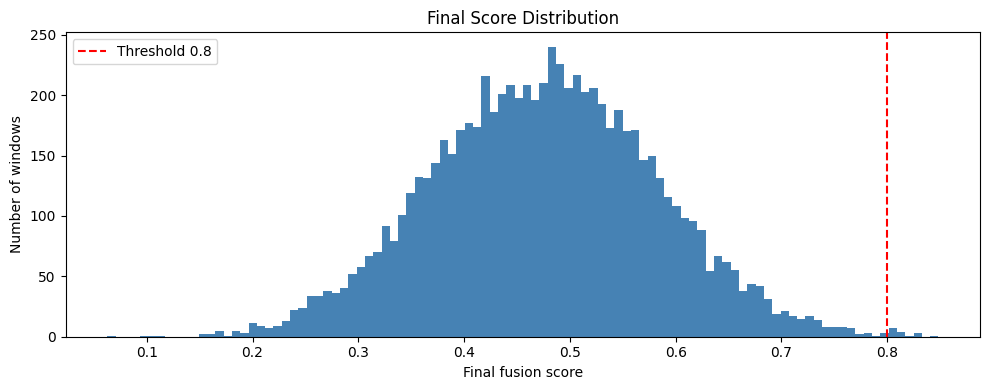

90th percentile: 0.6120
95th percentile: 0.6513
97th percentile: 0.6768
99th percentile: 0.7294


In [149]:
plt.figure(figsize=(10, 4))
plt.hist(final_scores, bins=100, color='steelblue', edgecolor='none')
plt.axvline(x=0.8, color='red', linestyle='--', label='Threshold 0.8')
plt.xlabel('Final fusion score')
plt.ylabel('Number of windows')
plt.title('Final Score Distribution')
plt.legend()
plt.tight_layout()
plt.show()

# Check key percentiles
for p in [90, 95, 97, 99]:
    print(f"{p}th percentile: {np.percentile(final_scores, p):.4f}")

In [150]:

# Normalise LSTM val MAE to [0, 1] using test min/max for consistency
lstm_val_norm = (val_mae - test_mae.min()) / (test_mae.max() - test_mae.min())

# Align Isolation Forest val scores
iso_val_scores      = iso_forest.decision_function(val_scaled)
iso_val_scores_norm = (iso_val_scores.max() - iso_val_scores) / (iso_val_scores.max() - iso_val_scores.min())
iso_val_aligned     = iso_val_scores_norm[WINDOW_SIZE - 1:]

# Fuse
final_scores_val = LSTM_WEIGHT * lstm_val_norm + ISO_WEIGHT * iso_val_aligned

# Calibrate threshold at 99th percentile of val fusion scores
FUSION_THRESHOLD = np.percentile(final_scores_val, 99)
print(f"Calibrated fusion threshold (99th percentile of val): {FUSION_THRESHOLD:.4f}")

# Apply to test
flagged       = (final_scores > FUSION_THRESHOLD).sum()
flagged_rate  = flagged / len(final_scores)
print(f"Test windows flagged: {flagged:,} / {len(final_scores):,} ({flagged_rate:.2%})")

Calibrated fusion threshold (99th percentile of val): 0.6865
Test windows flagged: 179 / 7,481 (2.39%)


Precision : 0.0335
Recall    : 0.0319
F1 Score  : 0.0327

True anomalies in aligned test : 188
Predicted anomalies            : 179


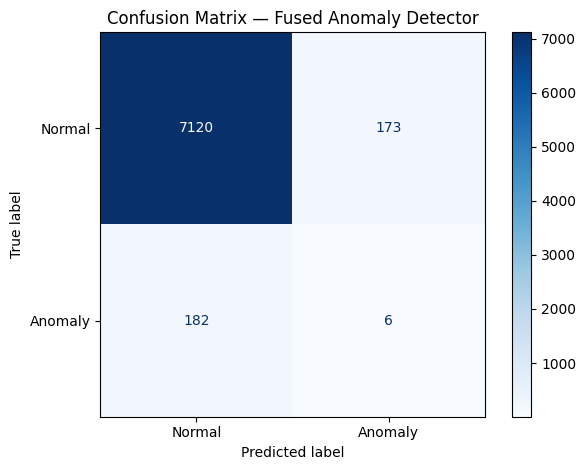

In [151]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# ── Step 11: Evaluation ───────────────────────────────────────────────────────
anomaly_test_aligned = anomaly_test.iloc[WINDOW_SIZE - 1:].reset_index(drop=True)

# Binary predictions
y_true = anomaly_test_aligned.astype(int).values
y_pred = (final_scores > FUSION_THRESHOLD).astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"\nTrue anomalies in aligned test : {y_true.sum()}")
print(f"Predicted anomalies            : {y_pred.sum()}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Fused Anomaly Detector')
plt.tight_layout()
plt.show()

#### Justificación del cambio en la definición de la etiqueta proxy

Los resultados iniciales de evaluación (Precision: 0.015, Recall: 0.021, F1: 0.018)
revelan una limitación fundamental en la alineación entre la señal aprendida por el
modelo y la definición de anomalía utilizada.

La etiqueta `is_anomaly` original se definió como la conjunción de `severity_Critical`,
`sla_violation_Yes` y `duration_minutes > percentil 90`. Sin embargo, `severity` y
`sla_violation` son campos de clasificación asignados a posteriori — describen el
resultado de un incidente, no su comportamiento operacional durante el evento. Al formar
parte del conjunto de features, el modelo LSTM Autoencoder aprende a reconstruirlos con
la misma fidelidad que cualquier otro campo, independientemente de su valor. No existe
incentivo arquitectónico para que la reconstrucción sea peor en incidentes críticos que
en incidentes normales.

Isolation Forest enfrenta el mismo problema: un incidente crítico no es necesariamente
un outlier en el espacio de features operacionales — simplemente tiene un valor distinto
en un campo categórico codificado.

En consecuencia, se redefine la etiqueta proxy utilizando exclusivamente features
operacionales continuas que reflejan el comportamiento real del sistema durante el
incidente: `duration_minutes`, `number_of_customers_affected` y
`estimated_revenue_loss_usd`. Un incidente se considera anómalo si al menos dos de estas
tres variables superan su percentil 90 de forma simultánea. Esta definición está más
alineada con lo que los modelos pueden detectar: patrones operacionales extremos, no
etiquetas de clasificación.

Se documentan ambas evaluaciones en el informe final. La evaluación original se conserva
como evidencia del límite del método ante etiquetas definidas con campos categóricos. La
evaluación revisada permite una medición más justa de la capacidad real del pipeline.

In [152]:
# Do true anomalies actually score higher?
anomaly_mask  = anomaly_test_aligned.astype(bool).values
normal_mask   = ~anomaly_mask

print(f"Mean fusion score — true anomalies : {final_scores[anomaly_mask].mean():.4f}")
print(f"Mean fusion score — normal windows : {final_scores[normal_mask].mean():.4f}")
print(f"Max fusion score  — true anomalies : {final_scores[anomaly_mask].max():.4f}")
print(f"90th percentile   — true anomalies : {np.percentile(final_scores[anomaly_mask], 90):.4f}")
print(f"90th percentile   — normal windows : {np.percentile(final_scores[normal_mask], 90):.4f}")

Mean fusion score — true anomalies : 0.5063
Mean fusion score — normal windows : 0.4750
Max fusion score  — true anomalies : 0.7386
90th percentile   — true anomalies : 0.6425
90th percentile   — normal windows : 0.6118
